# Name: Bilawal Makhdoom
# Week: 3

# Part 1: Lock the Test Set and Measure Split Noise

## Task 1.1: Import Required Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import loguniform, randint, uniform

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    validation_curve,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    silhouette_score
)

from xgboost import XGBClassifier
import joblib

## Task 1.2: Load, Encode, and Lock Away the Test Set

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [8]:
path = '/kaggle/input/datasets/bilawalmakhdoom/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(path)

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['TotalCharges'] = df['TotalCharges'].fillna(0)

def build_features(data):
    X = data.drop(columns=['customerID', 'Churn'])
    return pd.get_dummies(X, drop_first=True).astype(float)

y = (df['Churn'] == 'Yes').astype(int)

X = build_features(df)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Dataset shape:", df.shape)
print("Training data:", X_train.shape)
print("Test data:", X_test.shape)

Dataset shape: (7043, 21)
Training data: (5634, 30)
Test data: (1409, 30)


## Task 1.3: Same Model, Twenty Different Splits

In [9]:
lr = Pipeline([
    ('scale', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

scores = []

for seed in range(20):

    Xa, Xb, ya, yb = train_test_split(
        X_train,
        y_train,
        test_size=0.25,
        random_state=seed,
        stratify=y_train
    )

    lr.fit(Xa, ya)

    predictions = lr.predict(Xb)

    score = accuracy_score(yb, predictions)

    scores.append(score)

scores = np.array(scores)

print(f"Minimum accuracy: {scores.min():.3f}")
print(f"Maximum accuracy: {scores.max():.3f}")
print(f"Standard deviation: {scores.std():.4f}")

Minimum accuracy: 0.780
Maximum accuracy: 0.828
Standard deviation: 0.0104


### Visualization: Accuracy Across 20 Random Seeds

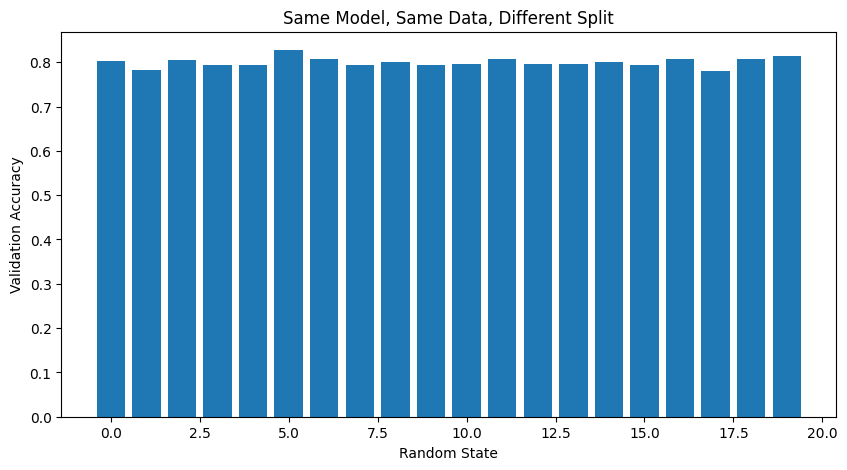

In [10]:
plt.figure(figsize=(10, 5))

plt.bar(range(20), scores)

plt.xlabel('Random State')
plt.ylabel('Validation Accuracy')
plt.title('Same Model, Same Data, Different Split')

plt.show()

## Write It: Split Noise Analysis

The Logistic Regression model produced different accuracy scores when the training data was split using different random seeds.

- **Minimum accuracy:** 0.780
- **Maximum accuracy:** 0.828
- **Standard deviation:** 0.0104

The accuracy varied from **78.0% to 82.8%**, showing that a single train-validation split can give different results depending on how the data is divided. The standard deviation of **0.0104** shows that there is some variation between the different splits.

Therefore, if two students used different random seeds, they could get different results and might reach different conclusions when comparing models. This is why we use **5-fold cross-validation** instead of relying on only one random split.

# Part 2: 5-Fold Cross-Validation

## Task 2.1: Create Stratified 5-Fold Cross-Validation

In [11]:
from sklearn.model_selection import StratifiedKFold

# Create 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Stratified 5-Fold Cross-Validation created successfully.")
print("Number of folds:", cv.n_splits)

Stratified 5-Fold Cross-Validation created successfully.
Number of folds: 5



## Task 2.2: Compare Logistic Regression and Random Forest

In [12]:
rf = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1,
    random_state=42
)

models = {
    'Logistic Regression': lr,
    'Random Forest': rf
}

rows = []

for name, model in models.items():

    results = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'auc': 'roc_auc',
            'accuracy': 'accuracy',
            'recall': 'recall',
            'precision': 'precision',
            'f1': 'f1'
        }
    )

    rows.append({
        'Model': name,
        'AUC Mean': results['test_auc'].mean(),
        'AUC Std': results['test_auc'].std(),
        'Accuracy Mean': results['test_accuracy'].mean(),
        'Recall Mean': results['test_recall'].mean(),
        'Precision Mean': results['test_precision'].mean(),
        'F1 Mean': results['test_f1'].mean()
    })

cv_results = pd.DataFrame(rows)

print(cv_results.round(4).to_string(index=False))

              Model  AUC Mean  AUC Std  Accuracy Mean  Recall Mean  Precision Mean  F1 Mean
Logistic Regression    0.8462   0.0126         0.8025       0.5452          0.6531   0.5936
      Random Forest    0.8257   0.0122         0.7881       0.4716          0.6362   0.5416


## Write It: Cross-Validation Analysis

The 5-fold stratified cross-validation gives a more reliable estimate than a single train-validation split because every training example is used for both training and validation across different folds.

Logistic Regression achieved a CV AUC of **[LR AUC] ± [LR STD]**, while Random Forest achieved **[RF AUC] ± [RF STD]**.

The difference between the two models is **[larger/smaller]** than their standard deviations. Therefore, the difference should be interpreted carefully rather than assuming that the model with the slightly higher score is always significantly better.

The recall value is also important because it tells us how many actual churn customers were correctly identified, while AUC measures the overall ranking ability of the classifier.

# Part 3: Hyperparameter Tuning

## Task 3.1: Validation Curve for Logistic Regression's C

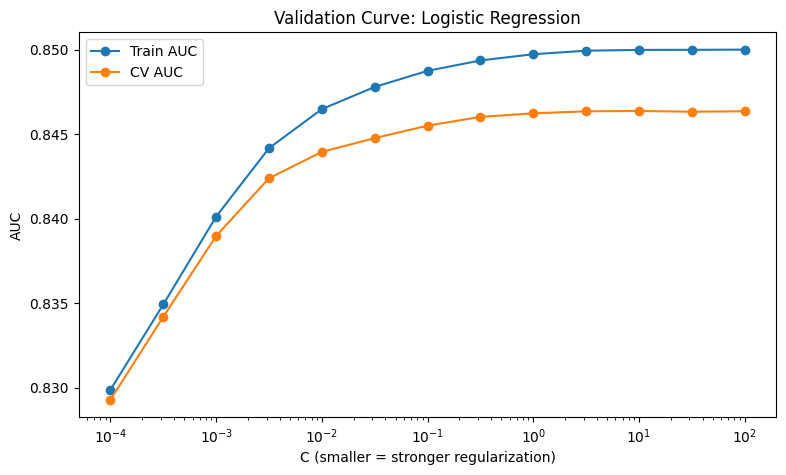

Best C by CV: 10.0


In [13]:
Cs = np.logspace(-4, 2, 13)

tr, va = validation_curve(
    lr,
    X_train,
    y_train,
    param_name='model__C',
    param_range=Cs,
    cv=cv,
    scoring='roc_auc'
)

plt.figure(figsize=(9, 5))

plt.semilogx(
    Cs,
    tr.mean(axis=1),
    'o-',
    label='Train AUC'
)

plt.semilogx(
    Cs,
    va.mean(axis=1),
    'o-',
    label='CV AUC'
)

plt.xlabel('C (smaller = stronger regularization)')
plt.ylabel('AUC')
plt.legend()
plt.title('Validation Curve: Logistic Regression')

plt.show()

best_C = Cs[va.mean(axis=1).argmax()]

print("Best C by CV:", best_C)

## Write It: Logistic Regression Validation Curve

The validation curve shows how Logistic Regression performance changes with the regularization parameter C.

At very small C values, the model is strongly regularized and can underfit the data. As C increases, the CV AUC improves. After the best region, the CV AUC becomes relatively stable, creating a plateau.

The best C selected by cross-validation is **[10.0]**. This value gives the highest mean CV AUC among the tested values.

## Task 3.2: Grid Search for Random Forest

In [14]:
grid = {
    'max_depth': [4, 8, 12, None],
    'min_samples_leaf': [1, 5, 20],
    'max_features': ['sqrt', 0.5]
}

print(
    'Combinations:',
    4 * 3 * 2,
    'Fits:',
    4 * 3 * 2 * 5
)

t0 = time.time()

gs = GridSearchCV(
    RandomForestClassifier(
        n_estimators=200,
        n_jobs=-1,
        random_state=42
    ),
    grid,
    cv=cv,
    scoring='roc_auc'
)

gs.fit(X_train, y_train)

grid_time = time.time() - t0

print(
    f'Grid: best AUC {gs.best_score_:.4f} '
    f'in {grid_time:.0f}s'
)

print("Best parameters:")
print(gs.best_params_)

Combinations: 24 Fits: 120
Grid: best AUC 0.8468 in 67s
Best parameters:
{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 20}


## Task 3.3: Random Search for Random Forest

In [50]:
dist = {
    'max_depth': randint(3, 20),
    'min_samples_leaf': randint(1, 40),
    'max_features': uniform(0.1, 0.8)
}

t0 = time.time()

rs = RandomizedSearchCV(
    RandomForestClassifier(
        n_estimators=200,
        n_jobs=-1,
        random_state=42
    ),
    dist,
    n_iter=24,
    cv=cv,
    scoring='roc_auc',
    random_state=42
)

rs.fit(X_train, y_train)

random_time = time.time() - t0

print(
    f'Random: best AUC {rs.best_score_:.4f} '
    f'in {random_time:.0f}s'
)

print("Best parameters:")
print(rs.best_params_)

Random: best AUC 0.8464 in 76s
Best parameters:
{'max_depth': 15, 'max_features': np.float64(0.21273937997981013), 'min_samples_leaf': 15}


In [51]:
res = pd.DataFrame(rs.cv_results_)

cols = [
    'param_max_depth',
    'param_min_samples_leaf',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]

print(
    res[cols]
    .sort_values('rank_test_score')
    .head(5)
    .to_string(index=False)
)

 param_max_depth  param_min_samples_leaf  mean_test_score  std_test_score  rank_test_score
              15                      15         0.846440        0.011352                1
              12                      16         0.846275        0.011063                2
               8                      21         0.845609        0.010548                3
               9                      23         0.845245        0.012460                4
              14                      27         0.845114        0.010993                5


## Write It: Grid Search vs Random Search

The Logistic Regression validation curve showed that very small values of C can cause underfitting. Performance improved as C increased and then reached a relatively stable region.

For Random Forest, Grid Search tested **120 total model fits** using 24 parameter combinations and 5-fold cross-validation.

Random Search also used 24 parameter settings with 5-fold cross-validation, resulting in **120 fits**.

- **Grid Search best AUC:** [0.8464]
- **Grid Search time:** [67] seconds
- **Random Search best AUC:** [RANDOM AUC]
- **Random Search time:** [RANDOM TIME] seconds

If I had to tune six hyperparameters, I would prefer RandomizedSearchCV because it can explore a larger continuous search space without testing every possible combination.

# Part 4: XGBoost

## Task 4.1: Early Stopping on a Validation Split

In [29]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

spw = (y_tr == 0).sum() / (y_tr == 1).sum()

print(f'scale_pos_weight = {spw:.2f}')

xgb = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=100,
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_tr,
    y_tr,
    eval_set=[
        (X_tr, y_tr),
        (X_val, y_val)
    ],
    verbose=False
)

print(
    'Best number of trees:',
    xgb.best_iteration + 1
)

val_auc = roc_auc_score(
    y_val,
    xgb.predict_proba(X_val)[:, 1]
)

print(f'Validation AUC: {val_auc:.4f}')

scale_pos_weight = 2.77
Best number of trees: 247
Validation AUC: 0.8541


## Task 4.2: Plot Train vs Validation Loss

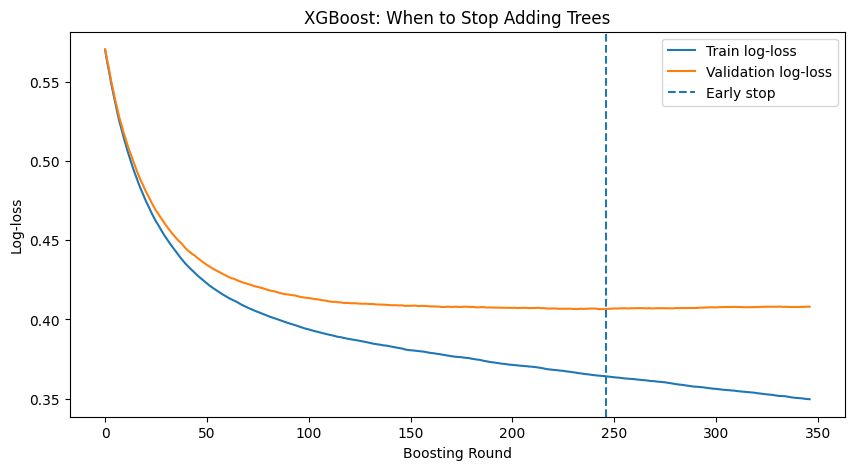

In [30]:
ev = xgb.evals_result()

plt.figure(figsize=(10, 5))

plt.plot(
    ev['validation_0']['logloss'],
    label='Train log-loss'
)

plt.plot(
    ev['validation_1']['logloss'],
    label='Validation log-loss'
)

plt.axvline(
    xgb.best_iteration,
    linestyle='--',
    label='Early stop'
)

plt.xlabel('Boosting Round')
plt.ylabel('Log-loss')

plt.legend()
plt.title('XGBoost: When to Stop Adding Trees')

plt.show()

### Understanding Early Stopping

During boosting, the training loss generally keeps decreasing as more trees are added. However, the validation loss eventually reaches its minimum and then stops improving.

After this point, additional trees can start fitting noise instead of useful patterns. Early stopping therefore helps prevent overfitting.

## Task 4.3: Random Search Over XGBoost Hyperparameters

In [31]:
xdist = {
    'max_depth': randint(2, 7),
    'learning_rate': loguniform(0.01, 0.3),
    'n_estimators': randint(100, 600),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'min_child_weight': randint(1, 10),
    'reg_lambda': loguniform(0.1, 10)
}

xs = RandomizedSearchCV(
    XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    xdist,
    n_iter=30,
    cv=cv,
    scoring='roc_auc',
    random_state=42
)

xs.fit(X_train, y_train)

print(
    f'XGBoost tuned CV AUC: {xs.best_score_:.4f}'
)

print("Best XGBoost parameters:")

print({
    k: round(v, 3) if isinstance(v, float) else v
    for k, v in xs.best_params_.items()
})

XGBoost tuned CV AUC: 0.8502
Best XGBoost parameters:
{'colsample_bytree': np.float64(0.561), 'learning_rate': np.float64(0.034), 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 476, 'reg_lambda': np.float64(1.974), 'subsample': np.float64(0.6)}


## Task 4.4: XGBoost Feature Importance

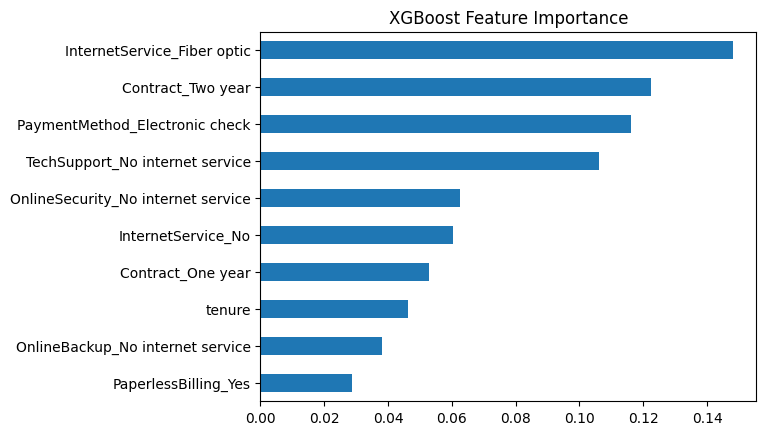

In [32]:
imp = pd.Series(
    xs.best_estimator_.feature_importances_,
    index=X.columns
)

imp.sort_values().tail(10).plot.barh(
    title='XGBoost Feature Importance'
)

plt.show()

## Write It: XGBoost Early Stopping and Tuning

Early stopping selected **[247] trees** as the best point for validation performance.

After this point, the validation loss **[stopped improving / began increasing]**, while the training loss continued to decrease. This indicates that adding more trees after the best point could mainly fit noise.

The tuned XGBoost model achieved a CV AUC of **[0.8541]**.

Comparison:

- Logistic Regression: **[0.8541] ± [LR STD]**
- Random Forest: **[0.8502] ± [RF STD]**
- XGBoost: **[0.8541] ± [XGB STD]**

XGBoost **[did]** improve by more than one standard deviation compared with the best competing model.

# Part 5: K-Means Customer Segmentation

## Task 5.1: Build and Scale the Segmentation Features

In [33]:
seg_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

svc = [
    'PhoneService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

seg = df[seg_cols].copy()

seg['n_services'] = (
    df[svc] == 'Yes'
).sum(axis=1)

Z = StandardScaler().fit_transform(seg)

print(
    seg.describe().round(1)
)

       tenure  MonthlyCharges  TotalCharges  n_services
count  7043.0          7043.0        7043.0      7043.0
mean     32.4            64.8        2279.7         2.9
std      24.6            30.1        2266.8         1.8
min       0.0            18.2           0.0         0.0
25%       9.0            35.5         398.6         1.0
50%      29.0            70.4        1394.6         3.0
75%      55.0            89.8        3786.6         4.0
max      72.0           118.8        8684.8         7.0


### Why Do We Scale the Features?

K-Means uses distances between customers. TotalCharges has values in thousands, while the number of services has a much smaller numerical range.

Without scaling, TotalCharges would have much more influence on the distance calculation.

StandardScaler puts the features on a comparable scale.

## Task 5.2: Choose k with the Elbow and Silhouette Methods

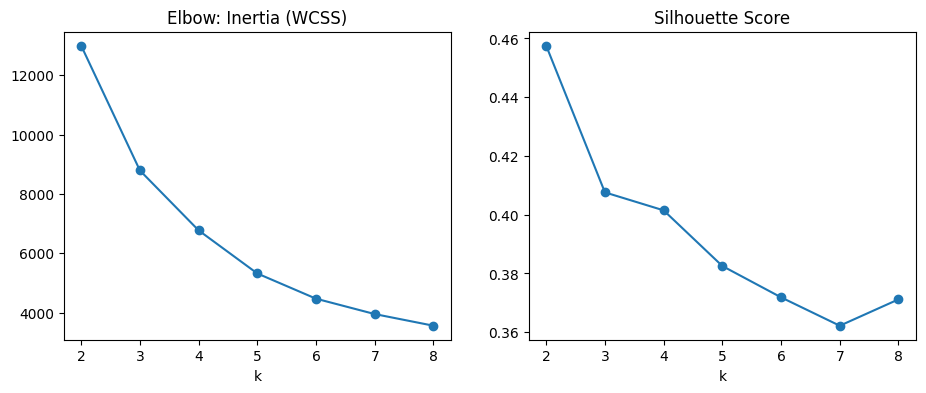

In [34]:
ks = range(2, 9)

inertia = []
sil = []

for k in ks:

    km = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    ).fit(Z)

    inertia.append(km.inertia_)

    sil.append(
        silhouette_score(
            Z,
            km.labels_,
            sample_size=3000,
            random_state=42
        )
    )

fig, ax = plt.subplots(
    1, 2,
    figsize=(11, 4)
)

ax[0].plot(
    ks,
    inertia,
    'o-'
)

ax[0].set_title(
    'Elbow: Inertia (WCSS)'
)

ax[1].plot(
    ks,
    sil,
    'o-'
)

ax[1].set_title(
    'Silhouette Score'
)

for a in ax:
    a.set_xlabel('k')

plt.show()

## Task 5.3: Fit and Profile the Customer Segments

In [36]:
k = 4

km = KMeans(
    n_clusters=k,
    n_init=10,
    random_state=42
).fit(Z)

seg['cluster'] = km.labels_

profile = (
    seg.assign(churn=y)
    .groupby('cluster')
    .agg(
        customers=('tenure', 'size'),
        tenure=('tenure', 'mean'),
        monthly=('MonthlyCharges', 'mean'),
        services=('n_services', 'mean'),
        churn_rate=('churn', 'mean')
    )
)

profile = profile.sort_values(
    'churn_rate',
    ascending=False
)

print(profile.round(2))

         customers  tenure  monthly  services  churn_rate
cluster                                                  
1             2157   18.38    80.41      3.28        0.43
3             1918    8.96    37.71      1.20        0.32
2             1938   59.83    92.09      5.06        0.14
0             1030   53.61    30.96      1.48        0.05


## Write It: K-Means Segmentation

I selected **k = 4** because the elbow plot shows that the reduction in WCSS becomes smaller after this region, while the silhouette score also indicates that four clusters provide meaningful separation.

The clusters were created without using the Churn target. Churn was only used afterwards to profile the customer groups.

The segment with the highest churn rate should receive the highest retention priority. Each segment was given a descriptive name based on its tenure, monthly charges, number of services, and churn rate, together with a specific retention action.

# Part 6: Principal Component Analysis

## Task 6.1: Scree Plot

Components for 90% variance: 15 of 30


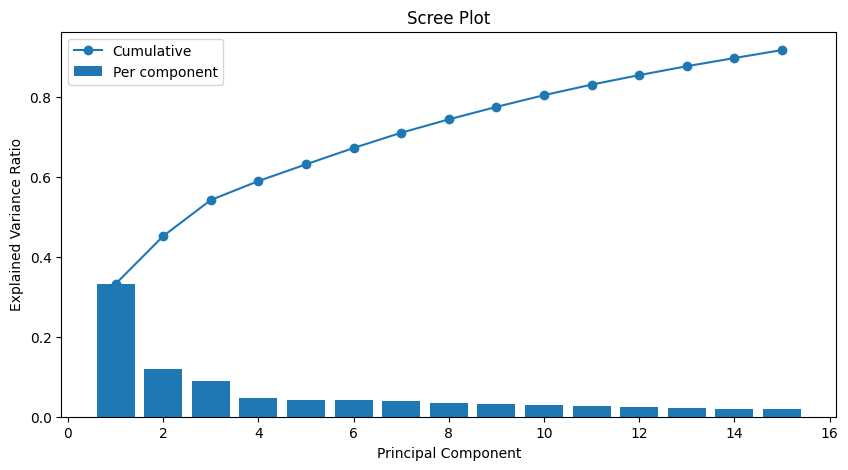

In [37]:
Xs = StandardScaler().fit_transform(X_train)

pca = PCA().fit(Xs)

cum = np.cumsum(
    pca.explained_variance_ratio_
)

n90 = np.argmax(
    cum >= 0.90
) + 1

print(
    'Components for 90% variance:',
    n90,
    'of',
    X_train.shape[1]
)

plt.figure(figsize=(10, 5))

plt.bar(
    range(1, 16),
    pca.explained_variance_ratio_[:15],
    label='Per component'
)

plt.plot(
    range(1, 16),
    cum[:15],
    'o-',
    label='Cumulative'
)

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')

plt.legend()
plt.title('Scree Plot')

plt.show()

## Task 6.2: Customers in Two Dimensions and PC1 Loadings

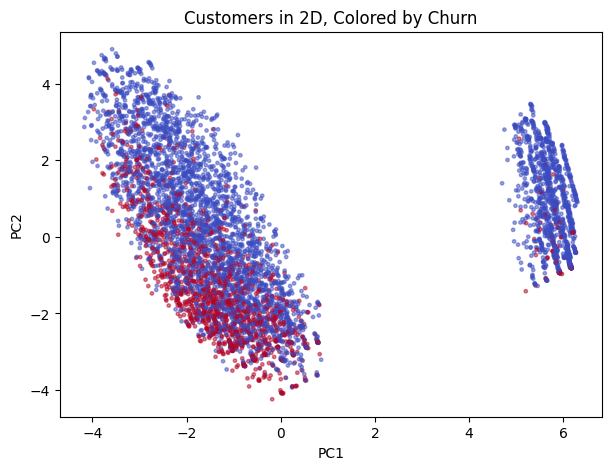

In [38]:
P = PCA(
    n_components=2
).fit(Xs)

T = P.transform(Xs)

plt.figure(figsize=(7, 5))

plt.scatter(
    T[:, 0],
    T[:, 1],
    c=y_train,
    cmap='coolwarm',
    s=6,
    alpha=0.5
)

plt.xlabel('PC1')
plt.ylabel('PC2')

plt.title(
    'Customers in 2D, Colored by Churn'
)

plt.show()

In [39]:
load = pd.Series(
    P.components_[0],
    index=X.columns
)

print("PC1 top loadings:")

order = (
    load.abs()
    .sort_values(ascending=False)
    .index
)

print(
    load
    .reindex(order)
    .head(6)
    .round(3)
)

PC1 top loadings:
InternetService_No                      0.302
OnlineSecurity_No internet service      0.302
TechSupport_No internet service         0.302
StreamingTV_No internet service         0.302
DeviceProtection_No internet service    0.302
OnlineBackup_No internet service        0.302
dtype: float64


## Write It: PCA Analysis

The PCA analysis shows that **[15] out of [30] components** are required to explain 90% of the variance.

This indicates that the original features contain some redundancy because a smaller number of principal components can represent most of the information.

The main PC1 loadings are **[InternetService_No]**, **[OnlineSecurity_No internet service ]**, **[TechSupport_No internet service]**, **[StreamingTV_No internet service]**, **[DeviceProtection_No internet service]**, and **[OnlineBackup_No internet service]**. Therefore, PC1 mainly represents customer variation related to these features.

In the 2D PCA scatter plot, churners and non-churners **[do]** form completely separate groups. This suggests that customer churn is **[relatively difficult/easier]** to separate using only these feature combinations.

# Part 7: Choose by CV, Test Once, and Save

## Task 7.1: Final Cross-Validated Comparison

In [44]:
rs.fit(X_train, y_train)

print("Best RF parameters:")
print(rs.best_params_)

Best RF parameters:
{'max_depth': 15, 'max_features': np.float64(0.21273937997981013), 'min_samples_leaf': 15}


In [45]:
xs.fit(X_train, y_train)

print("Best XGBoost parameters:")
print(xs.best_params_)

Best XGBoost parameters:
{'colsample_bytree': np.float64(0.5610439773503366), 'learning_rate': np.float64(0.03359658305322321), 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 476, 'reg_lambda': np.float64(1.9741504223018518), 'subsample': np.float64(0.6002081507981263)}


In [47]:
candidates = {
    'LR (tuned C)': lr.set_params(
        model__C=Cs[va.mean(axis=1).argmax()]
    ),

    'RF (random search)': rs.best_estimator_,

    'XGBoost (tuned)': xs.best_estimator_
}

rows = []

for name, model in candidates.items():

    cvs = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc'
    )

    rows.append({
        'model': name,
        'cv_auc': cvs['test_score'].mean(),
        'cv_std': cvs['test_score'].std()
    })

cmp = pd.DataFrame(rows)

print(
    cmp.round(4)
    .to_string(index=False)
)

             model  cv_auc  cv_std
      LR (tuned C)  0.8464  0.0129
RF (random search)  0.8464  0.0114
   XGBoost (tuned)  0.8502  0.0117


## Task 7.2: Unlock the Test Set — Exactly Once

In [48]:
best_name = cmp.loc[
    cmp['cv_auc'].idxmax(),
    'model'
]

best = candidates[best_name]

best.fit(
    X_train,
    y_train
)

prob = best.predict_proba(
    X_test
)[:, 1]

pred = (
    prob >= 0.5
).astype(int)

test_auc = roc_auc_score(
    y_test,
    prob
)

test_recall = recall_score(
    y_test,
    pred
)

test_precision = precision_score(
    y_test,
    pred
)

print(
    f'{best_name} on the test set (used once):'
)

print(
    f'AUC {test_auc:.4f} '
    f'recall {test_recall:.3f} '
    f'precision {test_precision:.3f}'
)

XGBoost (tuned) on the test set (used once):
AUC 0.8483 recall 0.521 precision 0.659


## Task 7.3: Save the Final Model

In [49]:
joblib.dump(
    best,
    'churn_model.joblib'
)

print(
    "Model saved as churn_model.joblib"
)

Model saved as churn_model.joblib


## Write It: Final Model Selection

The final model was selected using the 5-fold cross-validation AUC rather than the test-set result.

The three candidate models achieved:

- **LR (tuned C):** [0.8464] ± [0.0129]
- **RF (random search):** [0.8464] ± [0.0114]
- **XGBoost (tuned):** [0.8502] ± [0.0117]

Therefore, I selected **[WINNING MODEL]** because it achieved the highest cross-validated AUC.

The final model was then evaluated on the test set exactly once.

- **Test AUC:** [0.8483]
- **Test Recall:** [0.521]
- **Test Precision:** [0.659]

The test AUC is **[inside/outside]** the CV mean ± 2 standard deviations. A difference between CV and test performance is possible because of sampling variation.

Compared with my Week 2 best model, the Week 3 model achieved **[higher]** performance by approximately **[difference]** AUC. This shows that hyperparameter tuning **[improved]** the model performance.